# Comparação de modelos candidatos

Notebook integrado da comparação da Seção 4.4 (ART.7). Reúne, num só lugar, todos os modelos
candidatos à predição de Detrator, treinados sobre **a mesma matriz** e avaliados com **as mesmas
métricas e a mesma partição**, para que a equipe compare resultados de forma organizada.

A Seção 5 treina e registra os seis modelos de `scripts/comparar_seis_modelos.py`: cinco
candidatos (Extra Trees, Regressão Logística, Árvore de Decisão, Random Forest e Gradient Boosting)
e a Classe Majoritária, um piso de referência, e não um candidato. As partes comuns (carga,
pré-processamento, avaliação e visualização) também rodam sem modelos treinados.

## Como executar

```bash
pip install -r requirements.txt
jupyter lab notebooks/comparacao_modelos.ipynb
```

Para a execução verificável de ponta a ponta, a partir da raiz do repositório:

```bash
jupyter nbconvert --execute --to notebook --output-dir=.execucao notebooks/comparacao_modelos.ipynb
```

**Pré-requisito**: `data/processed/base_analitica.parquet`, gerada por
`notebooks/pre-processamento.ipynb`. A base não é versionada (o Termo de Abertura veda publicar
dados do parceiro).

**Sem acesso à base real**: gere a base sintética com `python scripts/gerar_dummy.py` e execute
`USAR_BASE_DUMMY=1 jupyter nbconvert --execute --to notebook --output-dir=.execucao notebooks/comparacao_modelos.ipynb`.
Ela serve só para verificar a execução, não para comparar modelos. No Jupyter, inicie o servidor
com `USAR_BASE_DUMMY=1 jupyter lab notebooks/comparacao_modelos.ipynb`.

**Como adicionar um candidato**: crie uma subseção na Seção 5 com justificativa e parâmetros,
instancie o estimador, ajuste-o somente com `X_treino` e `y_treino` e então registre o modelo
treinado em `modelos` com um nome único e acrescente-o à tabela do início da Seção 5. As seções 6 e
7 o incluem automaticamente. A seção 5.1 mostra a instanciação, o ajuste e o registro do primeiro
candidato.

Rode as células **em ordem**, de cima para baixo.

## 1. Importações

In [6]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
try:
    import sklearn
    from sklearn.dummy import DummyClassifier
    from sklearn.ensemble import (
        ExtraTreesClassifier,
        HistGradientBoostingClassifier,
        RandomForestClassifier,
    )
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
except ImportError as erro:
    raise ImportError(
        "Instale as dependências com pip install -r requirements.txt para usar os candidatos."
    ) from erro

# Inclui src/ no caminho de importação tanto no projeto local quanto no Colab.
for pasta_codigo in [Path("src"), Path("../src"), Path("/content/src")]:
    if pasta_codigo.exists():
        sys.path.insert(0, str(pasta_codigo.resolve()))
        break

from matriz import preparar_matriz
from modelo import metricas_no_teste

print(f"scikit-learn {sklearn.__version__}")

scikit-learn 1.9.1


## 2. Carregamento dos dados

`USAR_BASE_DUMMY = False` carrega a base analítica real, a única que mede o desempenho dos
candidatos. Com `True`, carrega a base sintética de `scripts/gerar_dummy.py`, que serve só para
verificar que o notebook roda sem o dado do parceiro: as métricas dela não valem para a comparação.

In [7]:
# No Colab, monte o Drive antes de rodar esta célula:
#   from google.colab import drive; drive.mount('/content/drive')

USAR_BASE_DUMMY = os.environ.get("USAR_BASE_DUMMY", "0") == "1"

if USAR_BASE_DUMMY:
    CAMINHOS_POSSIVEIS = [
        Path("data/dummy/base_analitica_dummy.parquet"),
        Path("../data/dummy/base_analitica_dummy.parquet"),
    ]
    instrucao = "Gere a base com: python scripts/gerar_dummy.py"
else:
    CAMINHOS_POSSIVEIS = [
        Path("data/processed/base_analitica.parquet"),
        Path("../data/processed/base_analitica.parquet"),
        Path("/content/data/processed/base_analitica.parquet"),
        Path("/content/drive/MyDrive/projeto-azul/data/processed/base_analitica.parquet"),
    ]
    instrucao = (
        "Rode notebooks/pre-processamento.ipynb antes. Para só verificar que o notebook "
        "roda, sem o dado do parceiro, defina USAR_BASE_DUMMY=1 no ambiente."
    )

caminho_base = next((c for c in CAMINHOS_POSSIVEIS if c.exists()), None)
if caminho_base is None:
    raise FileNotFoundError(f"{CAMINHOS_POSSIVEIS[0].name} não encontrada. {instrucao}")

df = pd.read_parquet(caminho_base)
print(f"{caminho_base}: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
if USAR_BASE_DUMMY:
    print("ATENÇÃO: base sintética. As métricas deste notebook não valem para a comparação.")

..\data\processed\base_analitica.parquet: 484,915 linhas x 52 colunas


## 3. Pré-processamento

`preparar_matriz`, de `src/matriz.py`, particiona por data e por Cliente, seleciona as features e
ajusta o pré-processador **apenas no treino**. É a única fonte de `X` e `y` do notebook: todo
candidato recebe exatamente a mesma matriz. As datas de corte vêm do registro de decisão do #127.

In [8]:
SEMENTE = 42
CORTE_VALIDACAO = "2025-07-01"
CORTE_TESTE = "2026-01-01"

preparo = preparar_matriz(df, corte_validacao=CORTE_VALIDACAO, corte_teste=CORTE_TESTE)

X_treino, y_treino = preparo["matrizes"]["treino"], preparo["y"]["treino"]
X_validacao, y_validacao = preparo["matrizes"]["validacao"], preparo["y"]["validacao"]
grupos_treino = preparo["grupos"]["treino"]

for nome in ("treino", "validacao", "teste"):
    m = preparo["matrizes"][nome]
    print(f"{nome}: {m.shape[0]:,} linhas x {m.shape[1]} colunas | "
          f"prevalência de Detrator {preparo['y'][nome].mean():.4f}")

treino: 341,962 linhas x 38 colunas | prevalência de Detrator 0.2043
validacao: 48,301 linhas x 38 colunas | prevalência de Detrator 0.2160
teste: 53,486 linhas x 38 colunas | prevalência de Detrator 0.2041


## 4. Registro dos modelos

`modelos` recebe apenas modelos já treinados com a matriz de treino: os cinco candidatos e o piso
de referência da seção 5.6. Enquanto estiver vazio, as seções 6 e 7 executam sem comparar
resultados.

In [9]:
modelos = {}

## 5. Modelos candidatos e piso de referência

Cada modelo ganha uma subseção com descrição, justificativa, parâmetros, treinamento e registro em
`modelos`. O nome registrado é o que aparece nas tabelas e nos gráficos das seções 6 e 7:

| Subseção | Nome em `modelos` | Papel | Origem dos hiperparâmetros |
| --- | --- | --- | --- |
| 5.1 | `Extra Trees` | candidato | configuração inicial, sem busca |
| 5.2 | `Regressão Logística` | candidato | busca em grade do card #210 |
| 5.3 | `Árvore de Decisão` | candidato | busca em grade dos cards #231 e #232 |
| 5.4 | `Random Forest` | candidato | padrão do scikit-learn, sem busca |
| 5.5 | `Gradient Boosting` | candidato | busca aleatória do card #190 |
| 5.6 | `Classe Majoritária` | piso de referência, não candidato | regra fixa, sem busca |

Os seis modelos e seus hiperparâmetros são os de `scripts/comparar_seis_modelos.py`. O script
ajusta Regressão Logística, Árvore de Decisão, Random Forest e Gradient Boosting como `Pipeline`
sobre as colunas cruas (`preparo["x"]`); aqui, cada estimador recebe `X_treino`. O ajuste é o
mesmo, porque o `Pipeline` usa um clone do pré-processador da Seção 3, ajustado sobre as mesmas
linhas de treino, e entrega ao estimador a mesma matriz. A única diferença de parâmetro é `n_jobs`
no Extra Trees, `-1` aqui e `1` no script: as árvores são as mesmas, e mudam só o tempo de ajuste
e, no máximo, o último bit de `predict_proba` (seção 5.4).

A avaliação não é a do script. O script mede, com `avaliar`, F2 e Sensibilidade no limiar por
capacidade, além de Precisão Média e ROC-AUC, na validação e no teste. Aqui, a comparação usa só as
três métricas da Seção 6 (`precisao_media`, `roc_auc` e `brier`), que não dependem de limiar, e só
na partição de validação. Os valores de F2 citados nas subseções são o critério de cada busca,
medido nos folds de validação cruzada dentro do treino, e não o desempenho comparado.

### 5.1. Extra Trees

Extra Trees permite testar, na mesma matriz com variáveis numéricas e categóricas codificadas,
interações e relações não lineares que um modelo linear pode não capturar. A aleatorização dos
limiares de divisão oferece uma alternativa aos outros ensembles para a comparação na validação;
isso é uma hipótese de modelagem, não um resultado de desempenho.

A configuração inicial reproduzível usa 300 árvores, `max_features='sqrt'`,
`min_samples_leaf=5`, `random_state=SEMENTE` (42) e `n_jobs=-1`. O peso `balanced` é
calculado exclusivamente a partir de `y_treino`, sem reamostrar nem usar a validação ou o
teste no ajuste. A seleção de hiperparâmetros permanece restrita à validação; não se presume
ganho de desempenho na classe minoritária.

In [10]:
# O ajuste recebe somente a matriz transformada pelo pre-processador treinado em X_treino.
modelo_extra_trees = ExtraTreesClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=SEMENTE,
    n_jobs=-1,
)
modelo_extra_trees.fit(X_treino, y_treino)
modelos["Extra Trees"] = modelo_extra_trees

### 5.2. Regressão Logística

A Regressão Logística é o candidato interpretável da comparação: ela modela o logito da
probabilidade de detração como combinação linear das colunas da matriz, e cada coeficiente
exponenciado é um odds ratio, legível sem técnica auxiliar. Ela é também a referência linear dos
ensembles, porque não representa interação entre variáveis: o quanto os demais candidatos a
superam é o que a interação vale nesta base.

Os hiperparâmetros abaixo não são configuração inicial. São os vencedores da busca em grade do
card #210, versionados em `assets/hiperparametros_logistica.json`. A busca percorreu 8 combinações
em 5 folds `GroupKFold` por `ID_GOLDENRECORD`, ordenadas por F2, e a vencedora obteve F2 médio de
0,5189 com desvio de 0,0035 entre os folds. `class_weight` foi o único eixo que moveu a métrica.

Dois parâmetros pedem leitura explícita:

- `l1_ratio=1.0` com `solver='liblinear'` é a **penalidade L1**. O argumento `penalty` está
  depreciado desde o scikit-learn 1.8 e `l1_ratio` passou a expressá-lo: `0.0` é L2 e `1.0` é L1.
- `max_iter=1600` é medição do card #206, não estimativa: nesta matriz o ajuste trunca nos 100
  do padrão da biblioteca, e coeficiente truncado é coeficiente provisório.

O peso `balanced` é calculado exclusivamente a partir de `y_treino`, sem reamostrar e sem usar a
validação ou o teste no ajuste. Ele foi escolhido por melhorar o F2, que depende de limiar,
enquanto as três métricas da Seção 6 não dependem de limiar. Como a reponderação desloca a
probabilidade predita para longe da prevalência real, ela piora o escore de Brier sem piorar a
ordenação: nesta linha, um Brier alto indica calibração deslocada, e não capacidade de ordenar
pior.

In [11]:
# O ajuste recebe somente a matriz transformada pelo pre-processador treinado em X_treino.
# Hiperparametros vencedores da busca do card #210 (assets/hiperparametros_logistica.json).
modelo_logistica = LogisticRegression(
    C=1.0,
    l1_ratio=1.0,             # 1.0 e a penalidade L1; `penalty` esta depreciado desde a 1.8
    solver="liblinear",
    class_weight="balanced",
    max_iter=1600,            # medido no card #206; os 100 do padrao truncam o ajuste
    random_state=SEMENTE,
)
modelo_logistica.fit(X_treino, y_treino)
modelos["Regressão Logística"] = modelo_logistica

### 5.3. Árvore de Decisão

A Árvore de Decisão é o segundo candidato interpretável da comparação, ao lado da Regressão
Logística: em vez de coeficientes, ela se lê como regras de condição, previsão e proporção de
Detrator na folha, extraídas e interpretadas nos cards #233 e #234. Ao contrário da Regressão
Logística, cada divisão depende das divisões acima dela, então a árvore representa interação entre
variáveis por construção.

Os hiperparâmetros abaixo não são configuração inicial. São os vencedores da busca em grade dos
cards #231 e #232, versionados em `src/hiperparametros_arvore.json`. A busca percorreu as 48
combinações da grade do card #228 em 5 folds `GroupKFold` por `ID_GOLDENRECORD`, ordenadas por F2,
e a vencedora obteve F2 médio de 0,5078 nos folds. Na base real, a árvore vencedora tem 32 folhas.

Três parâmetros pedem leitura explícita:

- `max_depth=5` e `min_samples_leaf=50` são também requisito de explicabilidade, e não só de
  ajuste: a grade limitou a profundidade a no máximo 6 e a folha a no mínimo 50 respostas para que
  a árvore final coubesse numa leitura de regras.
- `random_state=SEMENTE` fixa o desempate entre divisões de mesmo ganho. Sem ele, dois ajustes
  podem escolher colunas diferentes num empate e produzir regras diferentes.

O peso `balanced` é calculado exclusivamente a partir de `y_treino`, sem reamostrar e sem usar a
validação ou o teste no ajuste. Como na Regressão Logística, a reponderação desloca a
probabilidade predita para longe da prevalência real: nesta linha, um Brier alto indica calibração
deslocada, e não necessariamente ordenação pior.

In [12]:
# O ajuste recebe somente a matriz transformada pelo pre-processador treinado em X_treino.
# Hiperparametros vencedores da busca dos cards #231/#232 (src/hiperparametros_arvore.json).
modelo_arvore = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,              # teto tambem de explicabilidade: a arvore precisa virar regras
    min_samples_leaf=50,      # piso da grade do card #228; folha menor descreve ruido
    class_weight="balanced",
    random_state=SEMENTE,     # fixa o desempate entre divisoes de mesmo ganho
)
modelo_arvore.fit(X_treino, y_treino)
modelos["Árvore de Decisão"] = modelo_arvore

### 5.4. Random Forest

O Random Forest é um ensemble de árvores ajustadas de forma independente. Ao contrário do Extra
Trees (seção 5.1), cada árvore é ajustada sobre uma amostra bootstrap do treino e escolhe, entre as
colunas sorteadas para cada divisão, o melhor limiar, em vez de sorteá-lo. A média das árvores
reduz a variância de uma árvore isolada e preserva a capacidade de representar interação entre
variáveis; o custo é a interpretabilidade, que deixa de ser intrínseca.

Os hiperparâmetros abaixo **não** vêm de busca. São os padrões do scikit-learn 1.9.1, a linha de
base do card #187. O código declara os quatro hiperparâmetros que a documentação registra para ela:
100 árvores (`n_estimators=100`), profundidade livre (`max_depth=None`), `max_features='sqrt'` e
nenhuma reponderação (`class_weight=None`); os demais ficam no padrão da biblioteca. A busca
aleatória do card #189 ainda não tem vencedor versionado em
`assets/hiperparametros_random_forest.json`, e a Seção 4.4.4 da documentação registra os
vencedores como pendentes da execução. Portanto, a Seção 6 mede a linha de base do Random Forest,
e não um Random Forest otimizado.

`n_jobs=1` segue `ensembles.criar_pipeline_random_forest`. Com várias threads, as árvores são as
mesmas, mas `predict_proba` soma os votos na ordem em que as threads terminam, e essa ordem pode
mudar o último bit da probabilidade; num empate exato no limiar, o rótulo previsto pode mudar. Com
uma thread, o resultado se repete a cada execução, ao custo de um ajuste mais lento.

In [13]:
# O ajuste recebe somente a matriz transformada pelo pre-processador treinado em X_treino.
# Padroes do scikit-learn 1.9.1 (linha de base do card #187); nao e vencedor de busca.
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    class_weight=None,
    random_state=SEMENTE,
    n_jobs=1,                 # uma thread: predict_proba reproduzivel ate o ultimo bit
)
modelo_random_forest.fit(X_treino, y_treino)
modelos["Random Forest"] = modelo_random_forest

### 5.5. Gradient Boosting

O Gradient Boosting é o ensemble de árvores por boosting: em vez de agregar árvores independentes,
como o Extra Trees e o Random Forest, ele ajusta árvores em sequência, cada uma corrigindo o erro
acumulado pelas anteriores, e também representa interação entre variáveis por construção. A
implementação é o `HistGradientBoostingClassifier` do scikit-learn, escolhido no card #185 em vez
do `XGBClassifier` por não acrescentar dependência ao projeto.

Os hiperparâmetros abaixo não são configuração inicial. São os vencedores da busca aleatória do
card #190, versionados em `assets/hiperparametros_gradient_boosting.json`, o arquivo que
`ensembles.melhor_gradient_boosting()` lê. A busca sorteou 40 combinações do espaço do card #186
(`random_state=42`) e as avaliou em 5 folds `GroupKFold` por `ID_GOLDENRECORD`, ordenadas por F2;
a vencedora obteve F2 médio de 0,5318 com desvio de 0,0035 entre os folds. `class_weight` foi o
eixo que separou as combinações: com `balanced`, o F2 médio ficou entre 0,512 e 0,532; sem
reponderação, entre 0,311 e 0,330.

Três parâmetros pedem leitura explícita:

- `learning_rate` e `l2_regularization` estão com todas as casas decimais do JSON. Arredondá-los
  produziria outro ensemble, diferente do vencedor registrado.
- `early_stopping=False` não vem da busca: é fixado por `ensembles.criar_pipeline_gradient_boosting`
  (card #188). No padrão `'auto'`, a biblioteca separaria uma fatia aleatória do treino para a
  parada antecipada, e essa fatia ignoraria o agrupamento por `ID_GOLDENRECORD`.

Este modelo não é o primeiro candidato da Seção 4.3.2 da documentação (card #103). Aquele também é
um `HistGradientBoostingClassifier`, mas usa `modelo.HIPERPARAMETROS_CANDIDATO`, sem reponderação,
e não faz parte deste notebook.

O peso `balanced` é calculado exclusivamente a partir de `y_treino`, sem reamostrar e sem usar a
validação ou o teste no ajuste. Como na Regressão Logística, `balanced` venceu por melhorar o
F2, que depende de limiar: na validação, a Precisão Média e o ROC-AUC do vencedor ficaram
praticamente iguais aos da linha de base do card #188 (seção 11.4 de `notebooks/ensembles.ipynb`).
A reponderação desloca a probabilidade predita para longe da prevalência real: nesta linha, um
Brier alto indica calibração deslocada, e não ordenação pior.

In [14]:
# O ajuste recebe somente a matriz transformada pelo pre-processador treinado em X_treino.
# Hiperparametros vencedores da busca do card #190 (assets/hiperparametros_gradient_boosting.json).
modelo_gradient_boosting = HistGradientBoostingClassifier(
    learning_rate=0.049833191601257244,   # todas as casas do JSON; arredondar muda o ensemble
    max_iter=200,
    max_leaf_nodes=61,
    min_samples_leaf=150,
    l2_regularization=1.774425485152653,  # todas as casas do JSON
    class_weight="balanced",
    early_stopping=False,     # fixado no card #188; a fatia aleatoria ignoraria o Cliente
    random_state=SEMENTE,     # 42, o mesmo random_state registrado no JSON
)
modelo_gradient_boosting.fit(X_treino, y_treino)
modelos["Gradient Boosting"] = modelo_gradient_boosting

### 5.6. Classe Majoritária (piso de referência)

A Classe Majoritária **não é um candidato** e não pode ser escolhida na Seção 8. É o piso contra o
qual os cinco candidatos são lidos: um `DummyClassifier(strategy='most_frequent')`, a mesma regra
da seção 2.2 de `notebooks/modelagem.ipynb`, que responde sempre a classe mais frequente de
`y_treino`, a de não Detrator, sem usar nenhuma coluna da matriz.

Como a probabilidade de Detrator que o `DummyClassifier` emite é 0 em toda linha, os três valores
da Classe Majoritária na Seção 6 são conhecidos antes da execução:

- `precisao_media` igual à prevalência de Detrator na validação, porque um score constante não
  ordena ninguém;
- `roc_auc` igual a 0,5, o valor de quem ordena ao acaso;
- `brier` também igual à prevalência de Detrator na validação, porque cada Detrator conta erro 1:
  o modelo afirma com certeza que ninguém é Detrator.

Um candidato que não supere este piso em `precisao_media` e `roc_auc` não ordena os Clientes
melhor do que o acaso. No `brier`, este piso não é a régua de calibração: uma probabilidade
constante igual à prevalência p erra menos, com Brier p × (1 − p).

O classificador não tem hiperparâmetro a buscar nem usa semente: a estratégia `most_frequent` é
determinística.

In [15]:
# O fit recebe X_treino so pela interface do scikit-learn: a regra nao le nenhuma coluna.
# Piso de referencia, nao candidato: prediz sempre a classe mais frequente de y_treino.
modelo_classe_majoritaria = DummyClassifier(strategy="most_frequent")
modelo_classe_majoritaria.fit(X_treino, y_treino)
modelos["Classe Majoritária"] = modelo_classe_majoritaria

Os estimadores registrados foram ajustados apenas no treino. A Seção 6 os mede na validação temporal
agrupada; a partição de teste permanece intocada até a escolha final do modelo e do limiar.

## 6. Avaliação

Todos os modelos registrados, os cinco candidatos e o piso de referência, são medidos na partição
de **validação**, com as métricas do #105 (`metricas_no_teste` recebe a partição por parâmetro).
O teste fica reservado ao modelo final.

In [16]:
if modelos:
    resultados = metricas_no_teste(modelos, X_validacao, y_validacao)
    display(resultados.sort_values(resultados.columns[0], ascending=False))
else:
    resultados = pd.DataFrame()
    print("Nenhum candidato registrado em `modelos`.")

,precisao_media,roc_auc,brier
modelo,,,
Gradient Boosting,0.517397,0.733010,0.183273
Regressão Logística,0.501081,0.727293,0.187716
Extra Trees,0.485784,0.723247,0.193596
Árvore de Decisão,0.441549,0.679983,0.194678
Random Forest,0.427083,0.671643,0.158573
Classe Majoritária,0.216000,0.500000,0.216000


## 7. Visualização

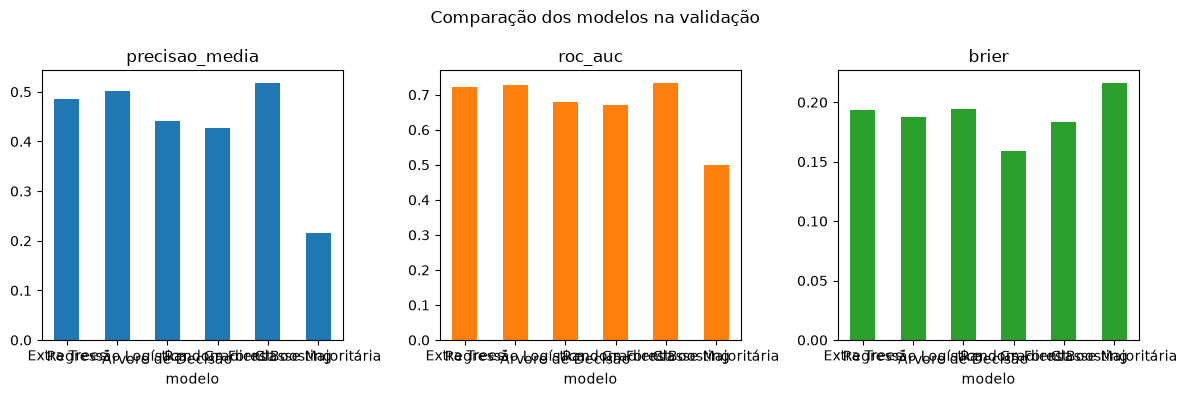

In [17]:
if resultados.empty:
    print("Sem resultados para visualizar.")
else:
    eixos = resultados.plot.bar(subplots=True, layout=(1, len(resultados.columns)),
                                figsize=(4 * len(resultados.columns), 4), legend=False, rot=0)
    plt.suptitle("Comparação dos modelos na validação")
    plt.tight_layout()
    plt.show()

## 8. Conclusão

*Preencher após a avaliação da Seção 6: qual candidato segue para o teste e por quê.*